# Quantum Amplitude Estimation Engine

Prices options using three QAE algorithms and compares them against Black Scholes and Monte Carlo.

**Algorithms implemented:**
- **Classical QAE** - QPE-based, deep circuits, exact in statevector simulation
- **IQAE** - Iterative QAE: shallow circuits, hardware-friendly, O(1/ε) oracle complexity
- **MLQAE** - Maximum-Likelihood QAE: fixed shot schedule + MLE post-processing

**Studies included:**
1. Single strike pricing - all methods vs BS vs market
2. Discretisation accuracy - how n_qubits affects grid resolution
3. Three way convergence - QAE O(1/ε) vs MC O(1/√N) on one plot
4. Noise sensitivity - how depolarising noise degrades QAE accuracy
5. Full strike sweep - QAE prices across all liquid strikes

All quantum circuits run on *classical simulators* (Aer). The O(1/ε) advantage is asymptotic and theoretical. The noise study and break-even analysis quantify why current NISQ hardware cannot yet realise this advantage.

## 1. Imports & Path Setup

In [1]:
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec
import qiskit, qiskit_aer, qiskit_finance

# ── PATH CONFIG ────────────────────────────────────────────────────────────────
PROJECT_ROOT = "."     # folder containing params.py, black_scholes.py,
                        # monte_carlo.py, quantum_ae.py
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# ───────────────────────────────────────────────────────────────────────────────

from params import SharedParameters
from BlackScholes import bs_price
from MonteCarlo import plainMC, antitheticMC, controlMC, quasiMC
from QuantumAE import classicalQAE, iterativeQAE, mlQAE, qaeConvergence, discretisation_report, noise_impact_study, QAEResult

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

COLORS = {
    'bs'            : '#222222',
    'plain_mc'      : '#378ADD',
    'antithetic_mc' : '#6BAED6',
    'control_var'   : '#1D9E75',
    'quasi_mc'      : '#8B49C2',
    'classical_qae' : '#D85A30',
    'iqae'          : '#E8831A',
    'mlqae'         : '#B8290A',
    'market'        : '#BA7517',
    'spot'          : '#888888',
    'noise'         : '#CC3333',
}

print("Imports OK.")

Imports OK.


## 2. List Available Snapshots

In [2]:
def list_snapshots(data_dir=DATA_DIR):
    if not os.path.exists(data_dir):
        print(f"Data directory not found: {os.path.abspath(data_dir)}")
        return []
    meta_files = sorted(f for f in os.listdir(data_dir) if f.endswith("_meta.json"))
    if not meta_files:
        print("No Snapshots found. Please run OptionsData.ipynb and download options data")
        return []
    slugs = []
    print(f"{'#':<3}  {'Slug':<48}  {'Ticker':<6}  {'Expiry':<12}  "
          f"{'Spot':>7}  {'DTE':>5}  {'T':>6}")
    print("─" * 100)
    for i, mf in enumerate(meta_files):
        with open(os.path.join(data_dir, mf)) as f:
            m = json.load(f)
        slug = mf.replace("_meta.json", "")
        slugs.append(slug)
        print(f"{i:<3}  {slug:<48}  {m['ticker']:<6}  {m['expiry']:<12}  "
              f"${m['spot']:>6.2f}  {m.get('dte','?'):>5}  {m['T']:>6.4f}")
    return slugs

available_slugs = list_snapshots()

#    Slug                                              Ticker  Expiry           Spot    DTE       T
────────────────────────────────────────────────────────────────────────────────────────────────────
0    MSFT_2026-07-10_20260602_0214                     MSFT    2026-07-10    $460.52     37  0.1014


## 3. Select Snapshot & Configure

QAE Specific notes:

- `N_Qubits = 5` -> 32 grid points. Good accuracy/speed balance for demo.
- `N_Qubits = 7` -> 128 grid points. Better accuracy, slower circuit build.
- Circuits grow exponentially with n_qubits - stay <= 7 in simulation.
- `BACKEND = 'statevector'` is exact and fastest for noiseless comparison.
- `BACKEND = 'shot'` simulates realistic shot noise.
- `BACKEND = 'noisy'` adds depolarising + readout errors.

In [22]:
# SNAPSHOT
SLUG = ""       # Paste slug or leave empty if using index
SLUG_INDEX = 0

# QAE CONFIG
N_QUBITS = 5            # state prep qubits (gird = 2**N_QUBITS points)
N_AE_QUBITS = 5         # evaluation qubits for classical QAE
EPSILON = 0.01          # IQAE target amplitude precisison
BACKEND = "shot"        # 'statevector / noisy / shot
NOISE_LEVEL = 0.001     # depolarising error rate (use for noisy backend)
Q = 0.0                 # continous dividend yield
N_SHOTS = 4096          # shots for shot/noisy backend

# CONVERGENCE STUDY
EPS_MIN = 0.001     
EPS_MAX = 0.1
N_EPS_PTS = 10          # points in epsilon grid
QAE_REPEATS = 3         # independent trials per epsilon

# NOISE STUDY
NOISE_MIN = 1e-4
NOISE_MAX = 0.05
N_NOISE_PTS = 8
NOISE_RPTS = 3

if not SLUG:
    if not available_slugs:
        raise RuntimeError("No Snapshots found. Please run OptionsData.ipynb and download options data")
    SLUG = available_slugs[SLUG_INDEX]
    
with open(os.path.join(DATA_DIR, f"{SLUG}_meta.json")) as f:
    meta = json.load(f)
    
calls_mkt = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_calls.csv"))
puts_mkt = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_puts.csv"))

S = float(meta['spot'])
r = float(meta['r'])
T = float(meta['T'])
TICKER = meta['ticker']
EXPIRY = meta['expiry']
DTE = meta.get('dte', round(T*365))

# Load prior engine results if available
bs_calls = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_bs_calls.csv")) \
           if os.path.exists(os.path.join(DATA_DIR, f"{SLUG}_bs_calls.csv")) else None
mc_calls = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_mc_calls.csv")) \
           if os.path.exists(os.path.join(DATA_DIR, f"{SLUG}_mc_calls.csv")) else None
mc_puts = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_mc_puts.csv")) \
           if os.path.exists(os.path.join(DATA_DIR, f"{SLUG}_mc_puts.csv")) else None
mc_conv  = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_mc_convergence.csv")) \
           if os.path.exists(os.path.join(DATA_DIR, f"{SLUG}_mc_convergence.csv")) else None
           
print(f"Snapshot  : {SLUG}")
print(f"Ticker    : {TICKER}  |  Expiry: {EXPIRY}  ({DTE} DTE)")
print(f"Spot      : ${S:.2f}  |  r: {r:.2%}  |  T: {T:.4f}y")
print(f"BS results: {'loaded' if bs_calls is not None else 'not found'}")
print(f"MC results: {'loaded' if mc_calls is not None else 'not found'}")
print(f"MC conv   : {'loaded' if mc_conv is not None else 'not found'}")
print(f"\nQAE config: n_qubits={N_QUBITS}  backend={BACKEND}  epsilon={EPSILON}  noise={NOISE_LEVEL}")
print(f"Grid pts  : {2**N_QUBITS} (2^{N_QUBITS})")

Snapshot  : MSFT_2026-07-10_20260602_0214
Ticker    : MSFT  |  Expiry: 2026-07-10  (37 DTE)
Spot      : $460.52  |  r: 3.60%  |  T: 0.1014y
BS results: loaded
MC results: loaded
MC conv   : loaded

QAE config: n_qubits=5  backend=shot  epsilon=0.01  noise=0.001
Grid pts  : 32 (2^5)


## Discretisation Study

Before running quantum circuits, understand how many qubits are needed for log normal grid to be accuate. This isolates grid error from estimation error.

ATM call: K=460.00  σ=36.91%  BS=22.6394

Discretisation study (n_qubits = 3 -> 9)...

  n_qubits   grid pts   QAE price    |vs BS|    % error   
  ───────────────────────────────────────────────────────
  3          8          69.345057    46.705700  206.303   
  4          16         29.884816    7.245460   32.004    
  5          32         23.418918    0.779561   3.443      recommended
  6          64         22.869219    0.229863   1.015     
  7          128        22.703291    0.063934   0.282     
  8          256        22.637796    0.001561   0.007     
  9          512        22.642331    0.002974   0.013     


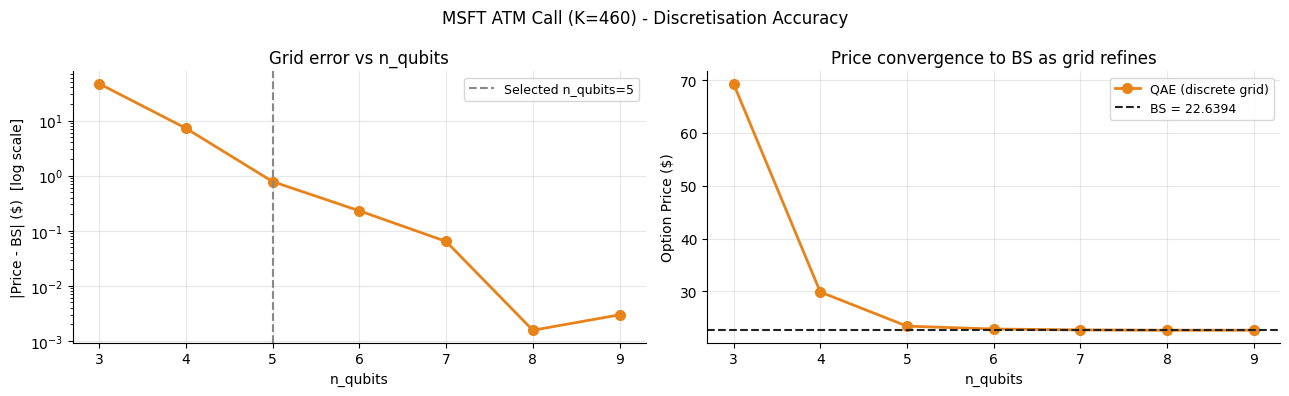

In [23]:
# Use ATM strke for study
atm_row = calls_mkt.iloc[(calls_mkt['strike'] - S).abs().argsort().iloc[0]]
K_atm = float(atm_row['strike'])
sigma_atm = float(atm_row['impliedVolatility'])
p_atm = SharedParameters(S=S, K=K_atm, r=r, sigma=sigma_atm, T=T)
bs_ref = bs_price(p_atm, 'call', q=Q)

print(f"ATM call: K={K_atm:.2f}  σ={sigma_atm:.2%}  BS={bs_ref:.4f}")
print(f"\nDiscretisation study (n_qubits = 3 -> 9)...")

qubit_range = list(range(3, 10))
disc = {'n_qubits': [], 'n_points': [], 'prices': [], 'errors': [], 'bs_ref': bs_ref}

for nq in qubit_range:
    rep = discretisation_report(p_atm, n_qubits=nq, q=Q, option_type='call')
    disc['n_qubits'].append(nq)
    disc['n_points'].append(rep['n_points'])
    disc['prices'].append(rep['discretised_price'])
    disc['errors'].append(rep['disc_error'])

print(f"\n  {'n_qubits':<10} {'grid pts':<10} {'QAE price':<12} {'|vs BS|':<10} {'% error':<10}")
print("  " + "─" * 55)

for i, nq in enumerate(disc['n_qubits']):
    pct = disc['errors'][i] / bs_ref * 100
    flag = " recommended" if nq==N_QUBITS else ""
    print(f"  {nq:<10} {disc['n_points'][i]:<10} {disc['prices'][i]:<12.6f} {disc['errors'][i]:<10.6f} {pct:<10.3f}{flag}")
    
# Plotting
fig, axes = plt.subplots(1,2, figsize=(13,4))
fig.suptitle(f"{TICKER} ATM Call (K={K_atm:.0f}) - Discretisation Accuracy", fontsize=12)

ax = axes[0]
ax.semilogy(disc['n_qubits'], disc['errors'], 'o-', color=COLORS['iqae'], lw=2, markersize=7)
ax.axvline(N_QUBITS, color=COLORS['spot'], lw=1.5, linestyle='--', label=f'Selected n_qubits={N_QUBITS}')
ax.set_xlabel('n_qubits'); ax.set_ylabel('|Price - BS| ($)  [log scale]')
ax.set_title('Grid error vs n_qubits'); ax.legend(fontsize=9)
ax.set_xticks(disc['n_qubits'])

ax = axes[1]
ax.plot(disc['n_qubits'], disc['prices'], 'o-', color=COLORS['iqae'], lw=2, markersize=7, label='QAE (discrete grid)')
ax.axhline(bs_ref, color=COLORS['bs'], lw=1.5, linestyle='--', label=f'BS = {bs_ref:.4f}')
ax.set_xlabel('n_qubits'); ax.set_ylabel('Option Price ($)')
ax.set_title('Price convergence to BS as grid refines')
ax.legend(fontsize=9); ax.set_xticks(disc['n_qubits'])

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_qae_discretisation.png"), dpi=150, bbox_inches='tight')
plt.show()

## Single Strike Pricing using QAE Methods
Price the ATM call with Classical QAE, IQAE, and MLQAE. Compare against BS and market mid.

In [24]:
from QuantumAE import LogNormalStatePrep
NOISE_P = 0.0       # depolarising noise per oracle call (0=ideal, 0.001=light noise)
M_EVAL = 6          # evaluation qubits for Classical QAE  (oracle calls = 2**M_EVAL)
mid_atm = float(atm_row['mid'])

print(f"ATM Call — {TICKER} | K={K_atm:.2f} | sigma={sigma_atm:.2%} | T={T:.4f}y")
print(f"  Market mid : ${mid_atm:.4f}")
print(f"  BS price   : ${bs_ref:.4f}")
print(f"  n_qubits   : {N_QUBITS}  ({2**N_QUBITS} grid pts)  |  noise_p={NOISE_P}\n")

qae_runs = [
    ('Classical QAE', COLORS['classical_qae'],
     lambda: classicalQAE(
         p_atm,
         n_qubits=N_QUBITS,
         m_eval=M_EVAL,           # m_eval, not n_ae_qubits
         option_type='call',
         q=Q,
         noise_p=NOISE_P,         # noise_p, not noise_level
     )),
    ('IQAE', COLORS['iqae'],
     lambda: iterativeQAE(
         p_atm,
         epsilon=EPSILON,
         n_qubits=N_QUBITS,
         option_type='call',
         q=Q,
         noise_p=NOISE_P,
     )),
    ('MLQAE', COLORS['mlqae'],
     lambda: mlQAE(
         p_atm,
         n_qubits=N_QUBITS,
         option_type='call',
         q=Q,
         noise_p=NOISE_P,
         # schedule and n_shots_each left as defaults
     )),
]

print(f"{'Method':<20}  {'Price':>9}  {'Stderr':>9}  {'|vs BS|':>9}  {'|vs Mkt|':>9}  {'CI width':>9}  {'Oracle':>10}  {'Depth':>7}  Time")
print("─" * 112)
print(f"{'Black-Scholes':<20}  {bs_ref:>9.4f}  {'—':>9}  {'—':>9}  {abs(bs_ref - mid_atm):>9.4f}")

single_results = {}
for name, colour, fn in qae_runs:
    t0 = time.perf_counter()
    res = fn()
    dt = time.perf_counter() - t0
    single_results[name] = res
    
    print(f"{name:<20}  {res.price:>9.4f}  {res.stderr:>9.6f}  {abs(res.price - bs_ref):>9.4f}  {abs(res.price - mid_atm):>9.4f}  "
            f"{res.ci_width:>9.4f}  {res.n_oracle:>10,}  {res.circuit_depth:>7}  {dt:.2f}s")
    

ATM Call — MSFT | K=460.00 | sigma=36.91% | T=0.1014y
  Market mid : $21.4500
  BS price   : $22.6394
  n_qubits   : 5  (32 grid pts)  |  noise_p=0.0

Method                    Price     Stderr    |vs BS|   |vs Mkt|   CI width      Oracle    Depth  Time
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Black-Scholes           22.6394          —          —     1.1894
Classical QAE           29.6476   9.810978     7.0082     8.1976    38.4583          64       64  0.00s
IQAE                    23.5265   0.424267     0.8871     2.0765     1.6631      67,000       61  0.00s
MLQAE                   23.5106   0.237024     0.8713     2.0606     0.9291      13,300       65  1.82s


## IQAE Iteration Diagnostics
IQAE narrows its confidence interval over successive rounds which is how it achieves O(1/epsilon) time complexity

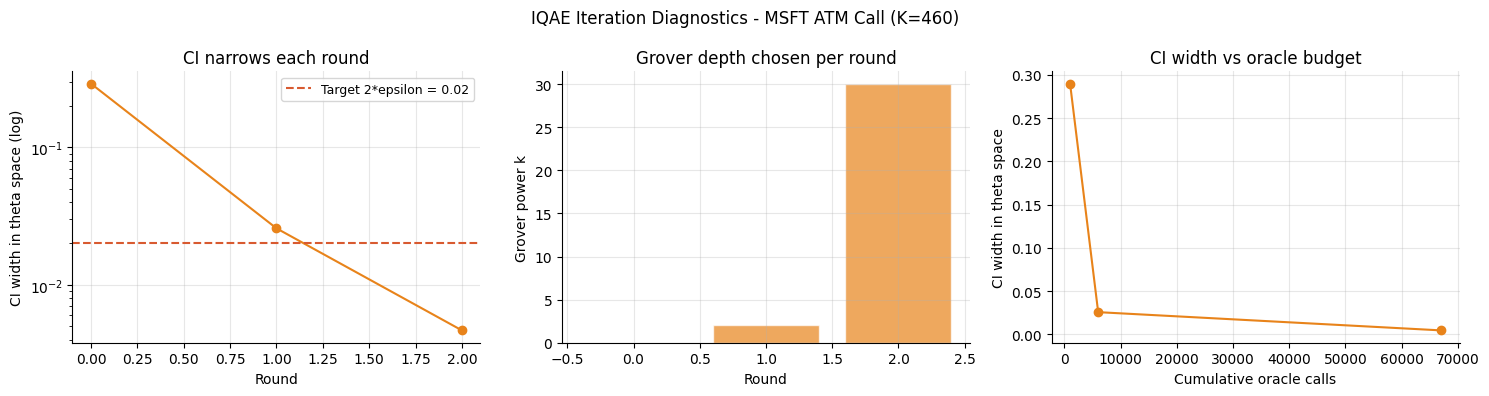

3 rounds  |  final CI width = 0.004660


In [25]:
iqae_res = single_results.get('IQAE')
history  = getattr(iqae_res, '_history', [])
# History dict keys: 'iter', 'k', 'depth', 'ci_width', 'n_oracle_cumulative'
 
if history:
    hist_df = pd.DataFrame(history)
 
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"IQAE Iteration Diagnostics - {TICKER} ATM Call (K={K_atm:.0f})", fontsize=12)
    
    ax = axes[0]
    ax.semilogy(hist_df['iter'], hist_df['ci_width'], 'o-', color=COLORS['iqae'], lw=1.5)
    ax.axhline(2 * EPSILON, color=COLORS['classical_qae'], lw=1.5, linestyle='--', label=f'Target 2*epsilon = {2*EPSILON}')
    ax.set_xlabel('Round')
    ax.set_ylabel('CI width in theta space (log)')
    ax.set_title('CI narrows each round')
    ax.legend(fontsize=9)
 
    ax = axes[1]
    ax.bar(hist_df['iter'], hist_df['k'], color=COLORS['iqae'], alpha=0.7, edgecolor='white')
    ax.set_xlabel('Round')
    ax.set_ylabel('Grover power k')
    ax.set_title('Grover depth chosen per round')
 
    ax = axes[2]
    ax.plot(hist_df['n_oracle_cumulative'], hist_df['ci_width'], 'o-', color=COLORS['iqae'], lw=1.5)
    ax.set_xlabel('Cumulative oracle calls')
    ax.set_ylabel('CI width in theta space')
    ax.set_title('CI width vs oracle budget')
 
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_qae_iqae_rounds.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{len(history)} rounds  |  final CI width = {history[-1]['ci_width']:.6f}")
else:
    print("No history - IQAE converged in 0 rounds (CI already narrow enough at start).")

## QAE Convergence Study

Sweep epsilon from coarse to fine and record error vs oracle calls. This produces the O(1/ε) curve.

In [26]:
EPS_VALUES  = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002]
eps_array = np.array(EPS_VALUES)
 
print(f"QAE convergence study  |  ATM call  |  {QAE_REPEATS} repeats per epsilon")
print(f"epsilon values: {EPS_VALUES}\n")

# qaeConvergence return keys: 'epsilon_values', 'n_oracle', 'mean_error', 'std_error', 'mean_stderr', 'method_name', 'noise_p'
t0 = time.perf_counter()
iqae_conv = qaeConvergence(
    p_atm, epsilon_values=eps_array, bs_price_ref=bs_ref, algorithm='iqae', n_qubits=N_QUBITS, option_type='call', q=Q, noise_p=NOISE_P, n_repeats=QAE_REPEATS,)
print(f"IQAE done in {time.perf_counter() - t0:.1f}s")
 
t0 = time.perf_counter()
mlqae_conv = qaeConvergence(
    p_atm, epsilon_values=eps_array, bs_price_ref=bs_ref, algorithm='mlqae', n_qubits=N_QUBITS, option_type='call', q=Q, noise_p=NOISE_P, n_repeats=QAE_REPEATS,)
print(f"MLQAE done in {time.perf_counter() - t0:.1f}s")

QAE convergence study  |  ATM call  |  3 repeats per epsilon
epsilon values: [0.1, 0.05, 0.02, 0.01, 0.005, 0.002]

IQAE done in 0.0s
MLQAE done in 33.6s


## Three-Way Convergence Plot

- **Monte Carlo methods** converge as O(1/√N) on a log-log error vs N plot
- **QAE** converges as O(1/ε) — plotted on the same axes using oracle calls as the x-axis

The break-even point (where QAE beats plain MC) and NISQ caveat are annotated.

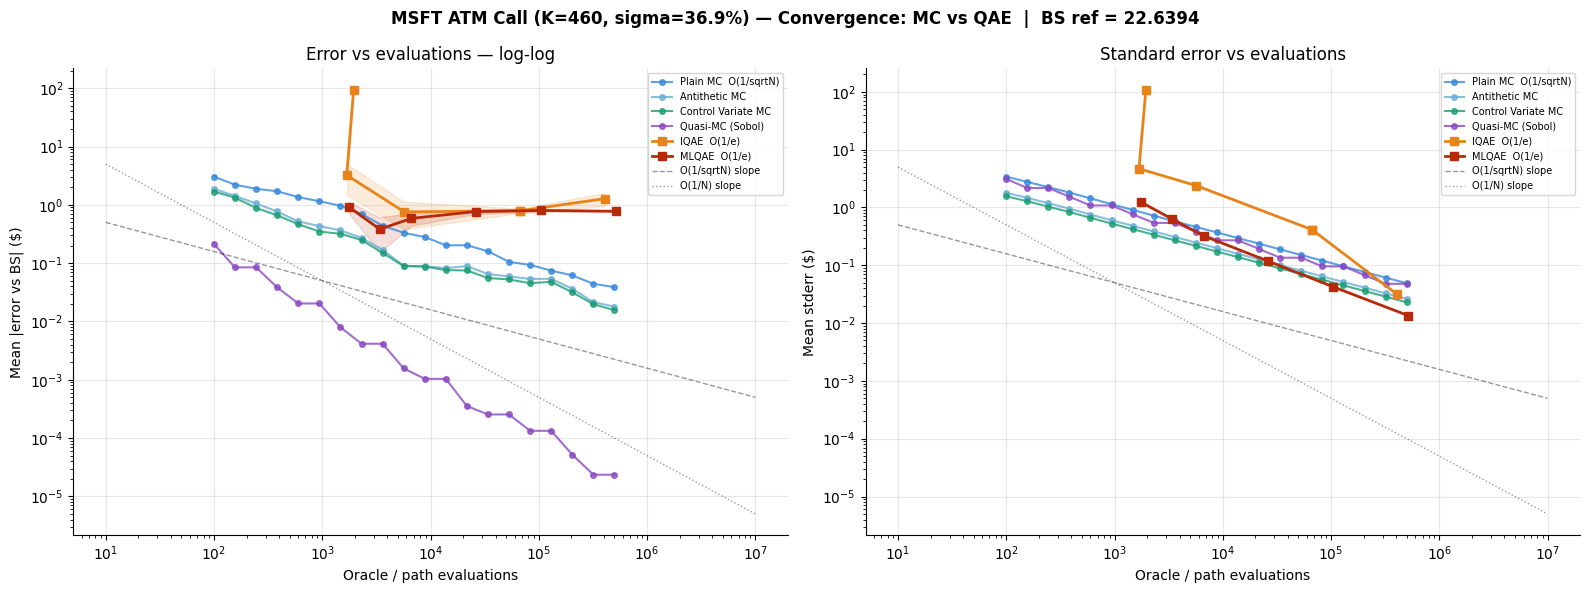

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"{TICKER} ATM Call (K={K_atm:.0f}, sigma={sigma_atm:.1%}) — Convergence: MC vs QAE  |  BS ref = {bs_ref:.4f}", fontsize=12, fontweight='bold')
 
for ax_idx, (y_col, ylabel, title) in enumerate([
    ('mean_error',  'Mean |error vs BS| ($)', 'Error vs evaluations — log-log'),
    ('mean_stderr', 'Mean stderr ($)',         'Standard error vs evaluations'),
]):
    ax = axes[ax_idx]
 
    # MC methods (x-axis = n_paths from mc_convergence CSV)
    if mc_conv is not None:
        for mc_label, color, display in [
            ('Plain MC',         COLORS['plain_mc'],     'Plain MC  O(1/sqrtN)'),
            ('Antithetic',       COLORS['antithetic_mc'], 'Antithetic MC'),
            ('Control Variate',  COLORS['control_var'],  'Control Variate MC'),
            ('Quasi-MC (Sobol)', COLORS['quasi_mc'],     'Quasi-MC (Sobol)'),
        ]:
            sub = mc_conv[mc_conv['method'] == mc_label].dropna(subset=[y_col])
            sub = sub[sub[y_col] > 0]
            if not sub.empty:
                ax.loglog(sub['n_paths'], sub[y_col], 'o-', color=color, lw=1.5, alpha=0.8,label=display, markersize=4)
    else:
        if ax_idx == 0:
            print("MonteCarlo convergence CSV not found — run MonteCarlo.ipynb first.")
 
    # QAE methods
    for conv_data, color, label in [
        (iqae_conv,  COLORS['iqae'],  'IQAE  O(1/e)'), (mlqae_conv, COLORS['mlqae'], 'MLQAE  O(1/e)'),]:
        oc   = conv_data['n_oracle']       # correct key
        yv   = conv_data[y_col]
        se   = conv_data['std_error']
        mask = (oc > 0) & (yv > 0)
        if mask.any():
            ax.loglog(oc[mask], yv[mask], 's-', color=color, lw=2, label=label, markersize=6, zorder=5)
            if ax_idx == 0:
                ax.fill_between(oc[mask], np.maximum(yv[mask] - se[mask], 1e-8), yv[mask] + se[mask], alpha=0.15, color=color)
 
    # Reference slope lines
    all_x = np.logspace(1, 7, 100)
    anchor_n, anchor_e = 1000, 0.05
    ax.loglog(all_x, anchor_e * (anchor_n / all_x) ** 0.5, 'k--', lw=1, alpha=0.4, label='O(1/sqrtN) slope')
    ax.loglog(all_x, anchor_e * (anchor_n / all_x) ** 1.0, 'k:',  lw=1, alpha=0.4, label='O(1/N) slope')
 
    ax.set_xlabel('Oracle / path evaluations')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right')
 
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_threeway_convergence.png"), dpi=150, bbox_inches='tight')
plt.show()

## Noise Sensitivity Study 

Sweeps depolarising noise level from near-zero (ideal) to 5% (aggressive NISQ noise). Shows how QAE degrades and at what noise level it loses its advantage over classical MC.

Noise sensitivity — IQAE  |  n_qubits=5  |  epsilon=0.01  |  3 repeats

Done in 0.0s


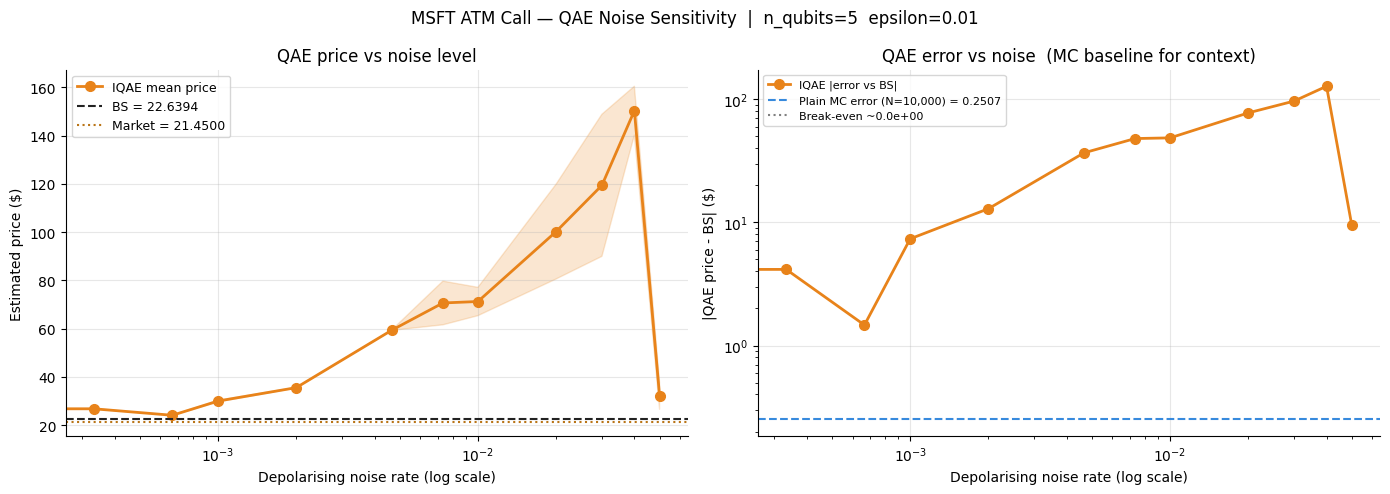


  BS ref                : $22.6394
  IQAE at noise=0       : $22.4424  (error 0.7884)
  IQAE at max noise     : $32.1739  (error 9.5345)
  Plain MC (N=10,000) : error 0.2507
  Current NISQ 2Q gate error ~0.1-1%  =>  noise_p ~ 0.001 to 0.01


In [28]:
# Noise study
NOISE_LEVELS = np.concatenate([
    np.linspace(0.0,  0.001, 4),
    np.linspace(0.002, 0.01, 4),
    np.linspace(0.02,  0.05, 4),])

print(f"Noise sensitivity — IQAE  |  n_qubits={N_QUBITS}  |  epsilon={EPSILON}  |  {NOISE_RPTS} repeats\n")
t0 = time.perf_counter()
noise_study = noise_impact_study(p_atm, noise_levels=NOISE_LEVELS, epsilon=EPSILON, n_qubits=N_QUBITS, option_type='call', q=Q, n_repeats=NOISE_RPTS,)
print(f"Done in {time.perf_counter() - t0:.1f}s")

# Plain MonteCarlo reference error for comparison
mc_ref_n   = 10_000
mc_ref_res = plainMC(p_atm, n_paths=mc_ref_n, option_type='call', seed=42)
mc_ref_err = abs(mc_ref_res.price - bs_ref)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{TICKER} ATM Call — QAE Noise Sensitivity  |  n_qubits={N_QUBITS}  epsilon={EPSILON}",fontsize=12)
 
ax = axes[0]
ax.semilogx(noise_study['noise_levels'], noise_study['mean_price'], 'o-', color=COLORS['iqae'], lw=2, markersize=7, label='IQAE mean price')

ax.fill_between(
    noise_study['noise_levels'],
    noise_study['mean_price'] - noise_study['std_error'],
    noise_study['mean_price'] + noise_study['std_error'],
    alpha=0.2, color=COLORS['iqae']
)
ax.axhline(bs_ref,  color=COLORS['bs'], lw=1.5, linestyle='--', label=f'BS = {bs_ref:.4f}')
ax.axhline(mid_atm, color=COLORS['market'], lw=1.5, linestyle=':', label=f'Market = {mid_atm:.4f}')
ax.set_xlabel('Depolarising noise rate (log scale)')
ax.set_ylabel('Estimated price ($)')
ax.set_title('QAE price vs noise level')
ax.legend(fontsize=9)
 
ax = axes[1]
ax.loglog(noise_study['noise_levels'], noise_study['mean_error'], 'o-', color=COLORS['iqae'], lw=2, markersize=7, label='IQAE |error vs BS|')
ax.axhline(mc_ref_err, color=COLORS['plain_mc'], lw=1.5, linestyle='--', label=f'Plain MC error (N={mc_ref_n:,}) = {mc_ref_err:.4f}')
 
cross_idx = np.where(noise_study['mean_error'] > mc_ref_err)[0]
if len(cross_idx) > 0:
    be_noise = noise_study['noise_levels'][cross_idx[0]]
    ax.axvline(be_noise, color='gray', lw=1.5, linestyle=':', label=f'Break-even ~{be_noise:.1e}')
 
ax.set_xlabel('Depolarising noise rate (log scale)')
ax.set_ylabel('|QAE price - BS| ($)')
ax.set_title('QAE error vs noise  (MC baseline for context)')
ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_qae_noise.png"), dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\n  BS ref                : ${bs_ref:.4f}")
print(f"  IQAE at noise=0       : ${noise_study['mean_price'][0]:.4f}  "
      f"(error {noise_study['mean_error'][0]:.4f})")
print(f"  IQAE at max noise     : ${noise_study['mean_price'][-1]:.4f}  "
      f"(error {noise_study['mean_error'][-1]:.4f})")
print(f"  Plain MC (N={mc_ref_n:,}) : error {mc_ref_err:.4f}")
print(f"  Current NISQ 2Q gate error ~0.1-1%  =>  noise_p ~ 0.001 to 0.01")

## Full Strike Sweep (IQAE across all liquid strikes)
Run IQAE (fastest QAE method) across all liquid call and put strikes for the full pricing comparison.

In [29]:
def price_all_strikes(df, option_type, S, r, T, q, n_qubits, epsilon, noise_p):
    records = []
    for x, row in df.iterrows():
        K = float(row['strike'])
        mid = float(row['mid'])
        sigma = float(row['impliedVolatility'])
        if sigma <=0:
            continue
        try:
            p = SharedParameters(S=S, K=K, r=r, sigma=sigma, T=T)
            bs_k = bs_price(p, option_type, q=q)
            res = iterativeQAE(p, epsilon=epsilon, n_qubits=n_qubits, option_type=option_type, q=q, noise_p=noise_p,)
            records.append({
                'strike'       : K,
                'moneyness'    : round(K / S, 4),
                'market_mid'   : round(mid, 4),
                'sigma'        : round(sigma, 4),
                'bs_price'     : round(bs_k, 4),
                'iqae_price'   : round(res.price, 4),
                'iqae_stderr'  : round(res.stderr, 6),
                'iqae_ci_lo'   : round(res.ci_low, 4),
                'iqae_ci_hi'   : round(res.ci_high, 4),
                'iqae_err_bs'  : round(res.price - bs_k, 4),
                'iqae_err_mkt' : round(res.price - mid, 4),
                'amplitude'    : round(res.amplitude, 6),
                'n_oracle'     : res.n_oracle,        # n_oracle not n_oracle_calls
                'circuit_depth': res.circuit_depth,
                'noise_level'  : res.noise_level,     # field exists on QAEResult
            })
        except Exception as e:
            records.append({'strike':K, 'erorr':str(e)})
    return pd.DataFrame(records)

print(f"Pricing {len(calls_mkt)} call strikes with IQAE...")
t0 = time.perf_counter()
calls_qae = price_all_strikes(calls_mkt, 'call', S, r, T, Q, N_QUBITS, EPSILON, NOISE_P)
print(f"  Done in {time.perf_counter() - t0:.1f}s")
 
print(f"Pricing {len(puts_mkt)} put strikes...")
t0 = time.perf_counter()
puts_qae = price_all_strikes(puts_mkt, 'put', S, r, T, Q, N_QUBITS, EPSILON, NOISE_P)
print(f"  Done in {time.perf_counter() - t0:.1f}s")
 
n_c = len(calls_qae.dropna(subset=['iqae_price']))
n_p = len(puts_qae.dropna(subset=['iqae_price']))
print(f"\nComplete: {n_c} calls, {n_p} puts priced.")
        

Pricing 38 call strikes with IQAE...
  Done in 0.0s
Pricing 27 put strikes...
  Done in 0.0s

Complete: 38 calls, 27 puts priced.


## Comparing BlackScholes vs MonteCarlo vs QAE

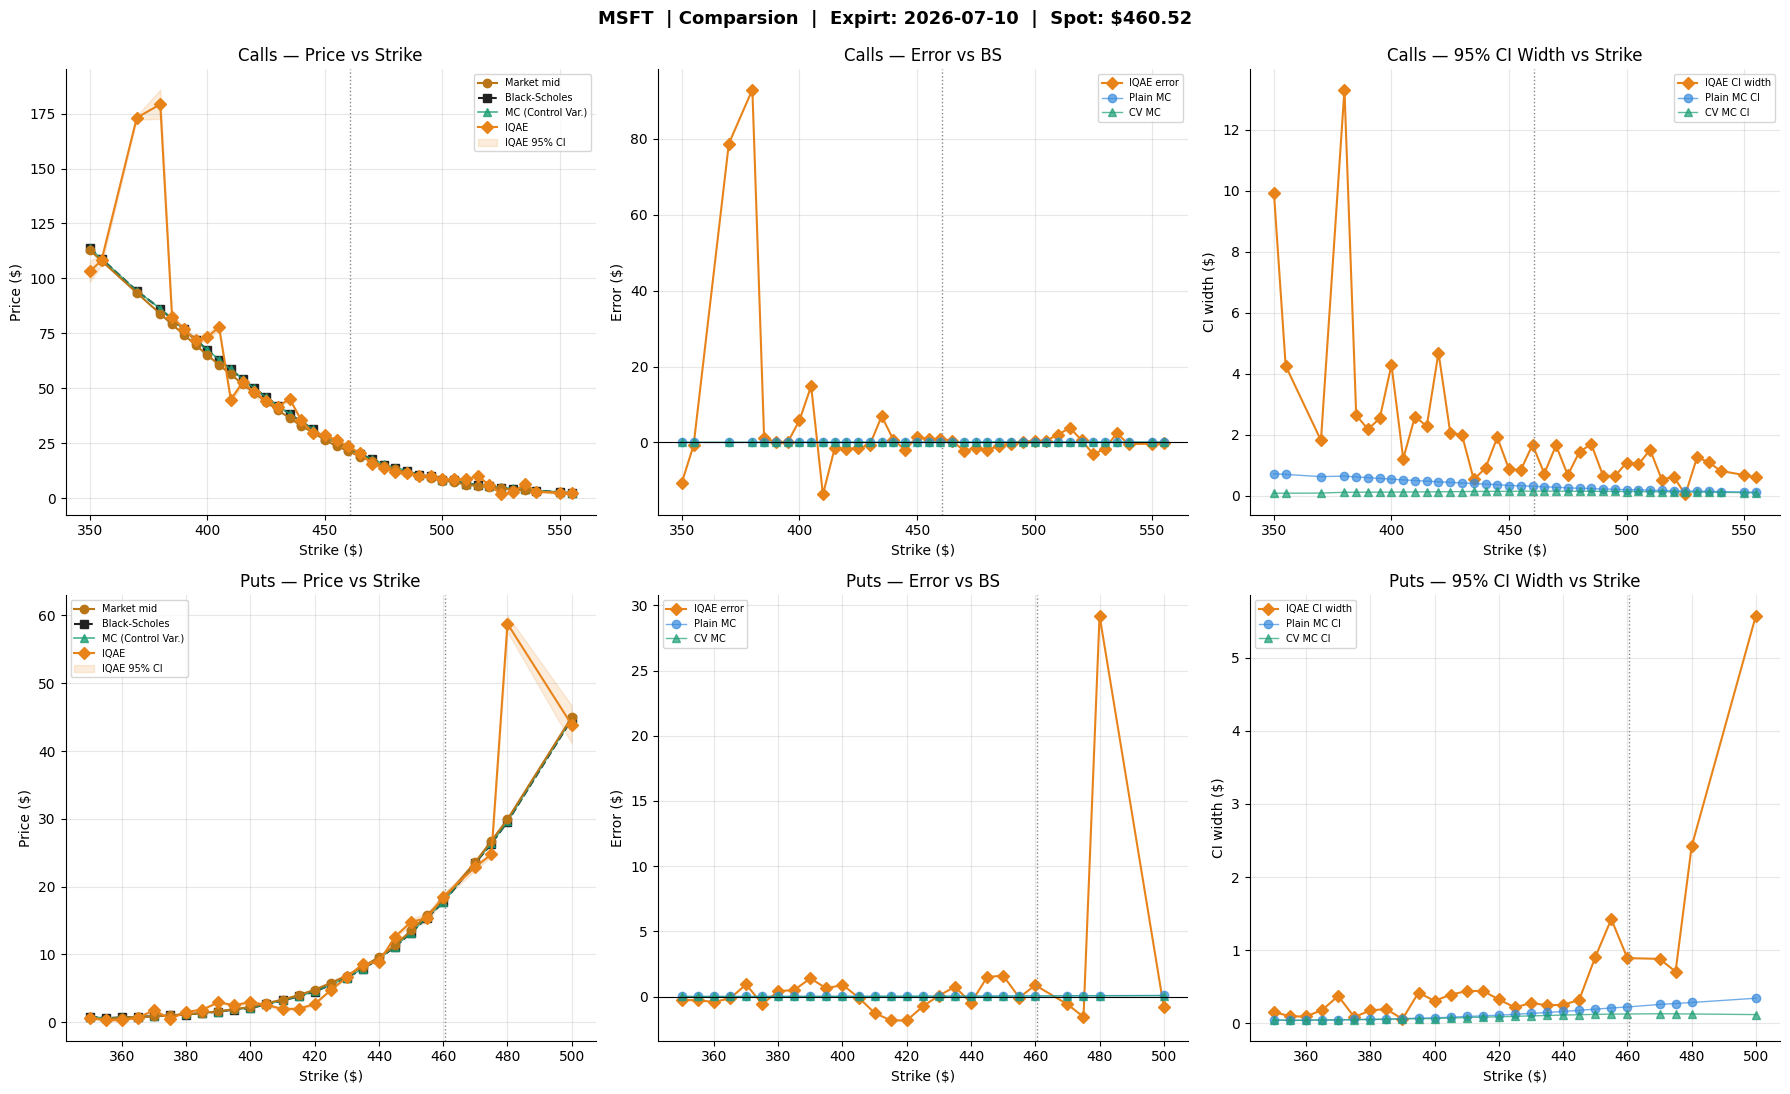

In [30]:
c = calls_qae.dropna(subset=['iqae_price'])
p = puts_qae.dropna(subset=['iqae_price'])

fig,axes = plt.subplots(2,3, figsize=(18,11))
fig.suptitle(f"{TICKER}  | Comparsion  |  Expirt: {EXPIRY}  |  Spot: ${S:.2f}", fontsize=13, fontweight='bold', y=0.99)

for row_idx, (df, label, mc_df) in enumerate([
    (c, 'Calls', mc_calls),
    (p, 'Puts', mc_puts),
]):
    
    ax = axes[row_idx, 0]
    ax.plot(df['strike'], df['market_mid'], 'o-', color=COLORS['market'], lw=1.5, label='Market mid', zorder=5)
    ax.plot(df['strike'], df['bs_price'], 's--', color=COLORS['bs'], lw=1.5, label='Black-Scholes')
    if mc_df is not None and 'cv_price' in mc_df.columns:
        m = mc_df[['strike', 'cv_price']].dropna()
        ax.plot(m['strike'], m['cv_price'], '^-', color=COLORS['control_var'], lw=1.2, alpha=0.8, label='MC (Control Var.)')
    ax.plot(df['strike'], df['iqae_price'], 'D-', color=COLORS['iqae'], lw=1.5, label='IQAE', zorder=5)
    ax.fill_between(df['strike'], df['iqae_ci_lo'], df['iqae_ci_hi'], alpha=0.15, color=COLORS['iqae'], label='IQAE 95% CI')
    ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
    ax.set_title(f'{label} — Price vs Strike')
    ax.set_xlabel('Strike ($)'); ax.set_ylabel('Price ($)')
    ax.legend(fontsize=7)
 
    # Error vs BS
    ax = axes[row_idx, 1]
    ax.plot(df['strike'], df['iqae_err_bs'], 'D-', color=COLORS['iqae'], lw=1.5, label='IQAE error')
    if mc_df is not None and 'plain_err_bs' in mc_df.columns:
        m = mc_df[['strike', 'plain_err_bs', 'cv_err_bs']].dropna()
        ax.plot(m['strike'], m['plain_err_bs'], 'o-', color=COLORS['plain_mc'],    lw=1, alpha=0.7, label='Plain MC')
        ax.plot(m['strike'], m['cv_err_bs'], '^-', color=COLORS['control_var'], lw=1, alpha=0.7, label='CV MC')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
    ax.set_title(f'{label} — Error vs BS')
    ax.set_xlabel('Strike ($)'); ax.set_ylabel('Error ($)')
    ax.legend(fontsize=7)
 
    # CI Width vs Strike
    ax = axes[row_idx, 2]
    ci_w = df['iqae_ci_hi'] - df['iqae_ci_lo']
    ax.plot(df['strike'], ci_w, 'D-', color=COLORS['iqae'], lw=1.5, label='IQAE CI width')
    if mc_df is not None and 'plain_stderr' in mc_df.columns:
        m = mc_df[['strike', 'plain_stderr', 'cv_stderr']].dropna()
        ax.plot(m['strike'], m['plain_stderr'] * 2 * 1.96, 'o-', color=COLORS['plain_mc'], lw=1, alpha=0.7, label='Plain MC CI')
        ax.plot(m['strike'], m['cv_stderr'] * 2 * 1.96, '^-', color=COLORS['control_var'], lw=1, alpha=0.7, label='CV MC CI')
    ax.axvline(S, color=COLORS['spot'], lw=1, linestyle=':')
    ax.set_title(f'{label} — 95% CI Width vs Strike')
    ax.set_xlabel('Strike ($)'); ax.set_ylabel('CI width ($)')
    ax.legend(fontsize=7)
 
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_qae_full_dashboard.png"), dpi=150, bbox_inches='tight')
plt.show()

## Summary and Break Even Analysis

In [31]:
ok = calls_qae.dropna(subset=['iqae_price'])

print("=" * 65)
print(f"SUMMARY — {TICKER} | {EXPIRY} | n_qubits={N_QUBITS} | epsilon={EPSILON}")
print("=" * 65)
if not ok.empty:
    print(f"  Strikes priced     : {len(ok)}")
    print(f"  Avg |error vs BS|  : ${ok['iqae_err_bs'].abs().mean():.4f}")
    print(f"  Max |error vs BS|  : ${ok['iqae_err_bs'].abs().max():.4f}")
    print(f"  Avg CI width       : ${(ok['iqae_ci_hi'] - ok['iqae_ci_lo']).mean():.4f}")
    print(f"  Avg oracle calls   : {ok['n_oracle'].mean():.0f}")
    print(f"  Avg circuit depth  : {ok['circuit_depth'].mean():.0f}")
 
print("\n" + "─" * 65)
print("COMPLEXITY COMPARISON")
print("─" * 65)
print(f"  {'Method':<22}  {'Complexity':<16}  Notes")
print(f"  {'Plain MC':<22}  {'O(1/e^2)':<16}  Baseline")
print(f"  {'Antithetic MC':<22}  {'O(1/e^2)':<16}  ~2x better constant")
print(f"  {'Control Variate':<22}  {'O(1/e^2)':<16}  10-100x better ATM")
print(f"  {'Quasi-MC (Sobol)':<22}  {'O(1/N.logN)':<16}  Better in practice")
print(f"  {'QAE (IQAE/MLQAE)':<22}  {'O(1/e)':<16}  Quadratic speedup (asymptotic)")
 
print("\n" + "─" * 65)
print("BREAK-EVEN ANALYSIS")
print("─" * 65)

for eps_t in [0.01, 0.001]:
    mc_n = int((1/eps_t)**2)
    qae_oc = int(np.pi/(4*eps_t))
    print(f"\n  epsilon = {eps_t}:")
    print(f"    Plain MC needs   : ~{mc_n:,} paths")
    print(f"    QAE needs        : ~{qae_oc:,} oracle calls")
    print(f"    Speedup factor   : {mc_n // qae_oc}x")
 
print("\n" + "─" * 65)
print("NISQ CHECK")
print("─" * 65)
if not ok.empty:
    d = ok['circuit_depth'].mean()
    print(f"  Avg circuit depth  : {d:.0f} gates")
    print(f"  At 0.1% gate error : ~{d * 0.001:.1%} accumulated noise")
    print(f"  At 1.0% gate error : ~{d * 0.01:.1%} accumulated noise")
print(f"  Current NISQ 2Q gate error: ~0.1-1%  (noise_p 0.001 to 0.01)")
print(f"  Fault-tolerant hardware with ~1e-4 gate error needed to")
print(f"  realise O(1/e) advantage in practice.")

SUMMARY — MSFT | 2026-07-10 | n_qubits=5 | epsilon=0.01
  Strikes priced     : 38
  Avg |error vs BS|  : $6.8390
  Max |error vs BS|  : $93.0129
  Avg CI width       : $2.0797
  Avg oracle calls   : 47079
  Avg circuit depth  : 42

─────────────────────────────────────────────────────────────────
COMPLEXITY COMPARISON
─────────────────────────────────────────────────────────────────
  Method                  Complexity        Notes
  Plain MC                O(1/e^2)          Baseline
  Antithetic MC           O(1/e^2)          ~2x better constant
  Control Variate         O(1/e^2)          10-100x better ATM
  Quasi-MC (Sobol)        O(1/N.logN)       Better in practice
  QAE (IQAE/MLQAE)        O(1/e)            Quadratic speedup (asymptotic)

─────────────────────────────────────────────────────────────────
BREAK-EVEN ANALYSIS
─────────────────────────────────────────────────────────────────

  epsilon = 0.01:
    Plain MC needs   : ~10,000 paths
    QAE needs        : ~78 oracle cal

## SAve Results

In [32]:
calls_out = os.path.join(DATA_DIR, f"{SLUG}_qae_calls.csv")
puts_out  = os.path.join(DATA_DIR, f"{SLUG}_qae_puts.csv")
calls_qae.to_csv(calls_out, index=False)
puts_qae.to_csv(puts_out,   index=False)
 
# Save QAE convergence data
conv_records = []
for conv_data, label in [(iqae_conv, 'IQAE'), (mlqae_conv, 'MLQAE')]:
    n = len(conv_data['mean_error'])
    for i in range(n):
        conv_records.append({
            'method'      : label,
            'epsilon'     : float(conv_data['epsilon_values'][i]),
            'n_oracle'    : float(conv_data['n_oracle'][i]),
            'mean_error'  : float(conv_data['mean_error'][i]),
            'std_error'   : float(conv_data['std_error'][i]),
            'mean_stderr' : float(conv_data['mean_stderr'][i]),
        })
 
conv_df  = pd.DataFrame(conv_records)
conv_out = os.path.join(DATA_DIR, f"{SLUG}_qae_convergence.csv")
conv_df.to_csv(conv_out, index=False)
 
print("Results saved:")
for path in [calls_out, puts_out, conv_out]:
    print(f"  {path}")

Results saved:
  ./data/MSFT_2026-07-10_20260602_0214_qae_calls.csv
  ./data/MSFT_2026-07-10_20260602_0214_qae_puts.csv
  ./data/MSFT_2026-07-10_20260602_0214_qae_convergence.csv
